# Travel Tactics - AI Multi-Agent Travel Planner

### Introduction
Travel planning is slow and fragmented. People switch between maps, blogs, reviews, budget spreadsheets, and more.

Travel Tactics solves this by combining multi-agent AI, tools, search, and memory into a single orchestrated travel planner.

The goal of Travel Tactics is to create an AI-powered system that:
- Understands a user’s travel request
- Gathers information using separate agents
- Generates an itinerary
- Simulates long operations
- Remembers user preferences

### Multi-Agent Architecture

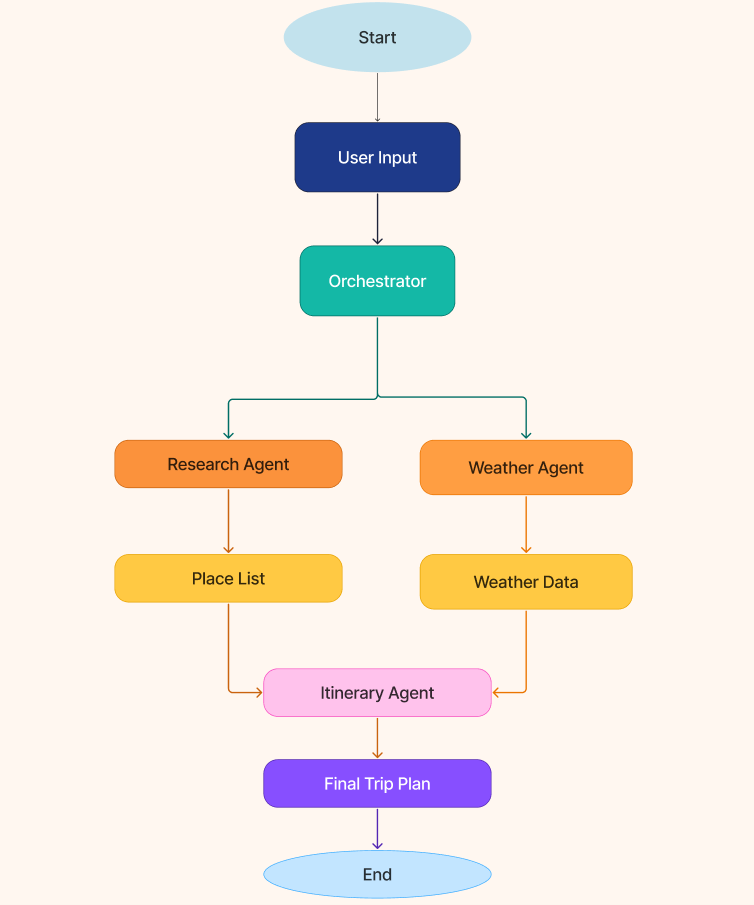

This clearly demonstrates sequential multi-agent execution, satisfying one of the core requirements.

### Environment Setup

In [1]:
import numpy as np
import pandas as pd
import os
import json
import time
import random
from typing import Dict, Any, List

### Custom Tools (Mock APIs)
In place of real APIs, we use mock tools to simulate:
- Weather data
- Attractions / places

In [2]:
def mock_weather_api(location: str):
    conditions = ["Sunny", "Cloudy", "Rainy", "Windy", "Snowy"]
    return {
        "location": location,
        "temp_c": random.randint(15, 30),
        "condition": random.choice(conditions)
    }

def mock_places_api(query: str):
    sample_data = {
        "delhi": ["India Gate", "Qutub Minar", "Lotus Temple"],
        "paris": ["Eiffel Tower", "Louvre Museum", "Notre Dame"],
        "tokyo": ["Shibuya Crossing", "Senso-ji Temple", "Tokyo Skytree"]
    }
    return sample_data.get(query.lower(), ["No results found"])

### Agents
We use 3 agents:
- Research Agent – finds top attractions
- Weather Agent – provides weather details
- Itinerary Agent – composes final itinerary

In [3]:
def research_agent(user_query: str):
    print("Research Agent Running...")
    places = mock_places_api(user_query)
    return {
        "query": user_query,
        "recommendations": places
    }

def weather_agent(city: str):
    print("Weather Agent Running...")
    return mock_weather_api(city)

def itinerary_agent(city: str, days: int):
    print("Itinerary Agent Running...")
    research = research_agent(city)
    weather = weather_agent(city)

    plan = []
    for i in range(days):
        place = research["recommendations"][i % len(research["recommendations"])]
        plan.append({
            "day": i+1,
            "place": place,
            "weather": weather["condition"]
        })

    return {
        "city": city,
        "weather": weather,
        "itinerary": plan
    }

### Orchestrator
This is the "brain" of the system.
It coordinates multiple agents sequentially.

In [4]:
def orchestrator(user_input: Dict[str, Any]):
    city = user_input["city"]
    days = user_input["days"]

    print("Orchestrating Travel Plan...\n")
    result = itinerary_agent(city, days)

    print("\nFinal Trip Plan Ready!\n")
    return result

### Demo: Generating a Trip Plan

In [5]:
user_request = {
    "city": "Tokyo",
    "days": 3
}

trip = orchestrator(user_request)
trip

Orchestrating Travel Plan...

Itinerary Agent Running...
Research Agent Running...
Weather Agent Running...

Final Trip Plan Ready!



{'city': 'Tokyo',
 'weather': {'location': 'Tokyo', 'temp_c': 18, 'condition': 'Snowy'},
 'itinerary': [{'day': 1, 'place': 'Shibuya Crossing', 'weather': 'Snowy'},
  {'day': 2, 'place': 'Senso-ji Temple', 'weather': 'Snowy'},
  {'day': 3, 'place': 'Tokyo Skytree', 'weather': 'Snowy'}]}

### Showing Itinery Table

In [6]:
df = pd.DataFrame(trip["itinerary"])
df

,day,place,weather
0,1,Shibuya Crossing,Snowy
1,2,Senso-ji Temple,Snowy
2,3,Tokyo Skytree,Snowy


### Long-Running Task Simulation
This simulates something like booking generation or flight search.

In [7]:
def long_running_task():
    print("Generating bookings...\n")
    for i in range(5):
        print(f"Step {i+1}/5 completed")
        time.sleep(0.5)
    return "Long-running job finished!"

long_running_task()

Generating bookings...

Step 1/5 completed
Step 2/5 completed
Step 3/5 completed
Step 4/5 completed
Step 5/5 completed


'Long-running job finished!'

### Simple Memory Storage
Tracks user preferences across steps

In [8]:
session_memory = []

def remember(x):
    session_memory.append(x)

def recall():
    return session_memory

remember("User likes vegetarian food")
remember("User prefers museums")

recall()

['User likes vegetarian food', 'User prefers museums']

### Exporting Trip as JSON File

In [9]:
with open("trip_plan.json", "w") as f:
    json.dump(trip, f, indent=4)

"trip_plan.json saved successfully"

'trip_plan.json saved successfully'

### Testing the System
These tests show the system works with:
- different cities
- different number of days
- invalid input

In [10]:
def test(city, days):
    print(f"\nTrip to: {city}, {days} days")
    try:
        result = orchestrator({"city": city, "days": days})
        print(pd.DataFrame(result["itinerary"]))
    except Exception as e:
        print("Error:", e)

test("Delhi", 2)
test("Paris", 5)
test("known City", 2)


Trip to: Delhi, 2 days
Orchestrating Travel Plan...

Itinerary Agent Running...
Research Agent Running...
Weather Agent Running...

Final Trip Plan Ready!

   day        place weather
0    1   India Gate   Snowy
1    2  Qutub Minar   Snowy

Trip to: Paris, 5 days
Orchestrating Travel Plan...

Itinerary Agent Running...
Research Agent Running...
Weather Agent Running...

Final Trip Plan Ready!

   day          place weather
0    1   Eiffel Tower  Cloudy
1    2  Louvre Museum  Cloudy
2    3     Notre Dame  Cloudy
3    4   Eiffel Tower  Cloudy
4    5  Louvre Museum  Cloudy

Trip to: known City, 2 days
Orchestrating Travel Plan...

Itinerary Agent Running...
Research Agent Running...
Weather Agent Running...

Final Trip Plan Ready!

   day             place weather
0    1  No results found   Rainy
1    2  No results found   Rainy
